In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import json
from tqdm import tqdm
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  

import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torch import nn

from datasets import DatasetDIDC, LazyDatasetDIDC
from unet_advanced import UNetAdvanced as UNetGan
from unet_advanced import UNetAdvanced
from diffusers import UNet2DModel, DDPMScheduler, AutoencoderKL
from datasets import FastDatasetDIDC 

%load_ext autoreload
%autoreload 2


In [2]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Selected device: {device}")
print(f'Num available GPUs: ', torch.cuda.device_count())


p = torch.cuda.get_device_properties()
print(f"Device: {p.name} (Memory: {p.total_memory / 1e9:.2f} GB)")

Selected device: cuda
Num available GPUs:  1
Device: NVIDIA TITAN RTX (Memory: 25.19 GB)


## GAN training CoroV2 basic benchmark

In [6]:
DATA_DIR = "./DIDC_multiclass_coro_v2_prep"

In [7]:
dir_name = 'experiments/DIDCV2/20260225_1710_MT_DIDC_basic_gan'

Foreground file for patient DIDC-350-T01_multiclass not found at ./DIDC_multiclass_coro_v2_prep/DIDC-350-T01_multiclass_fg.npy. Skipping.
Foreground file for patient DIDC-501-T01_multiclass not found at ./DIDC_multiclass_coro_v2_prep/DIDC-501-T01_multiclass_fg.npy. Skipping.
Foreground file for patient DIDC-482-T01_multiclass not found at ./DIDC_multiclass_coro_v2_prep/DIDC-482-T01_multiclass_fg.npy. Skipping.
Foreground file for patient DIDC-289-T01_multiclass not found at ./DIDC_multiclass_coro_v2_prep/DIDC-289-T01_multiclass_fg.npy. Skipping.
Foreground file for patient DIDC-346-T01_multiclass not found at ./DIDC_multiclass_coro_v2_prep/DIDC-346-T01_multiclass_fg.npy. Skipping.
Foreground file for patient DIDC-185-T01_multiclass not found at ./DIDC_multiclass_coro_v2_prep/DIDC-185-T01_multiclass_fg.npy. Skipping.
Foreground file for patient DIDC-488-T01_multiclass not found at ./DIDC_multiclass_coro_v2_prep/DIDC-488-T01_multiclass_fg.npy. Skipping.
Foreground file for patient DIDC-2

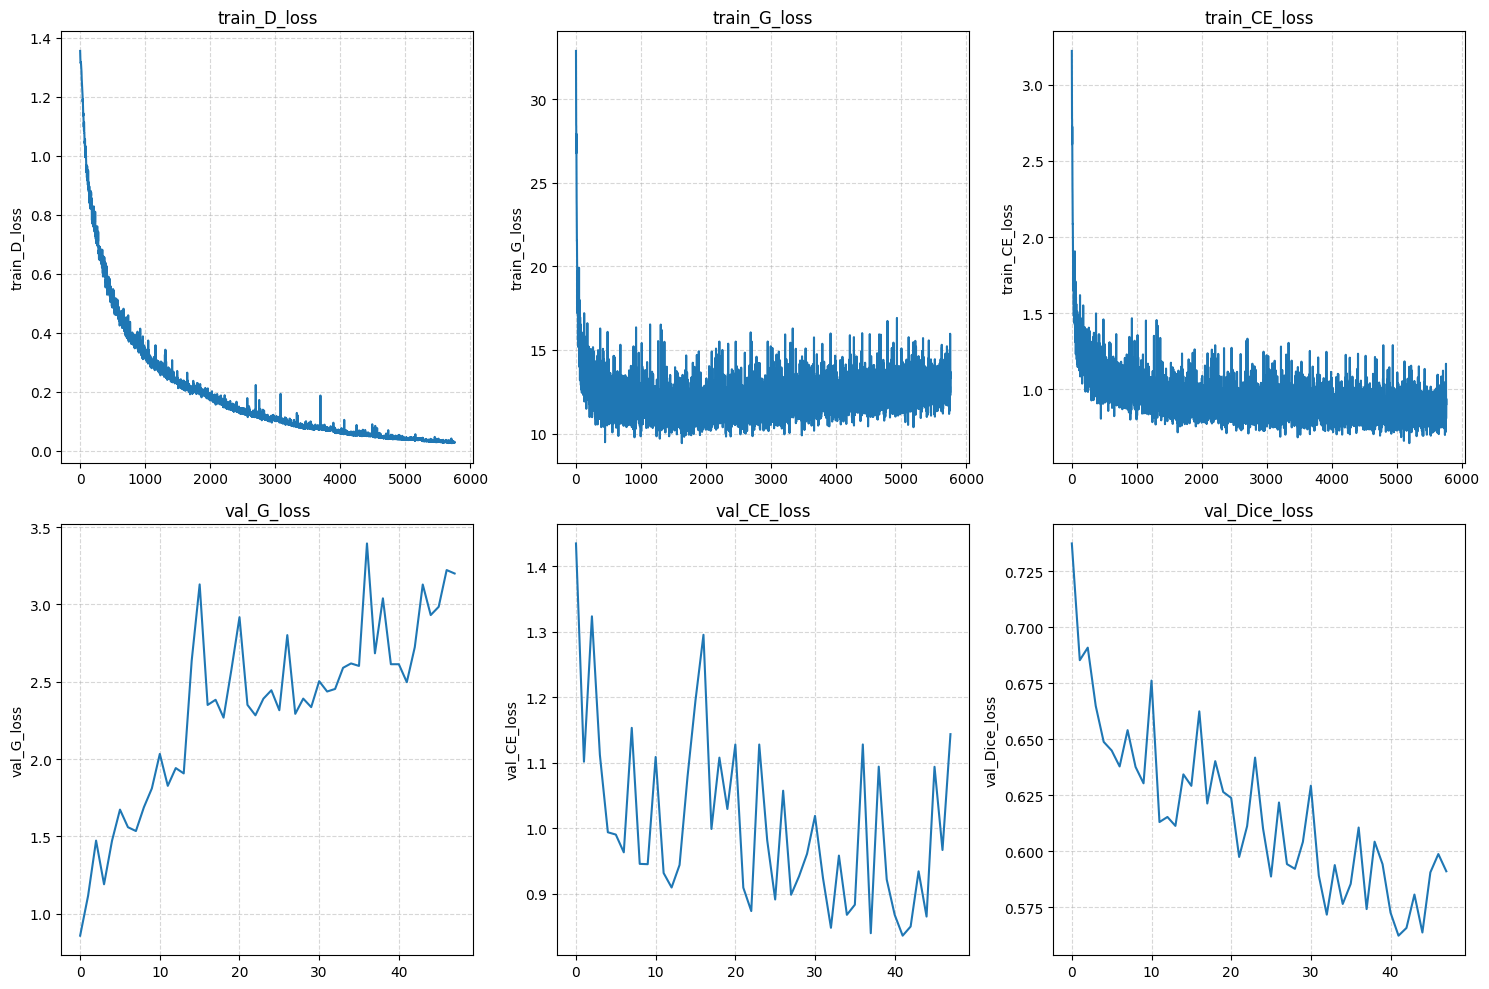

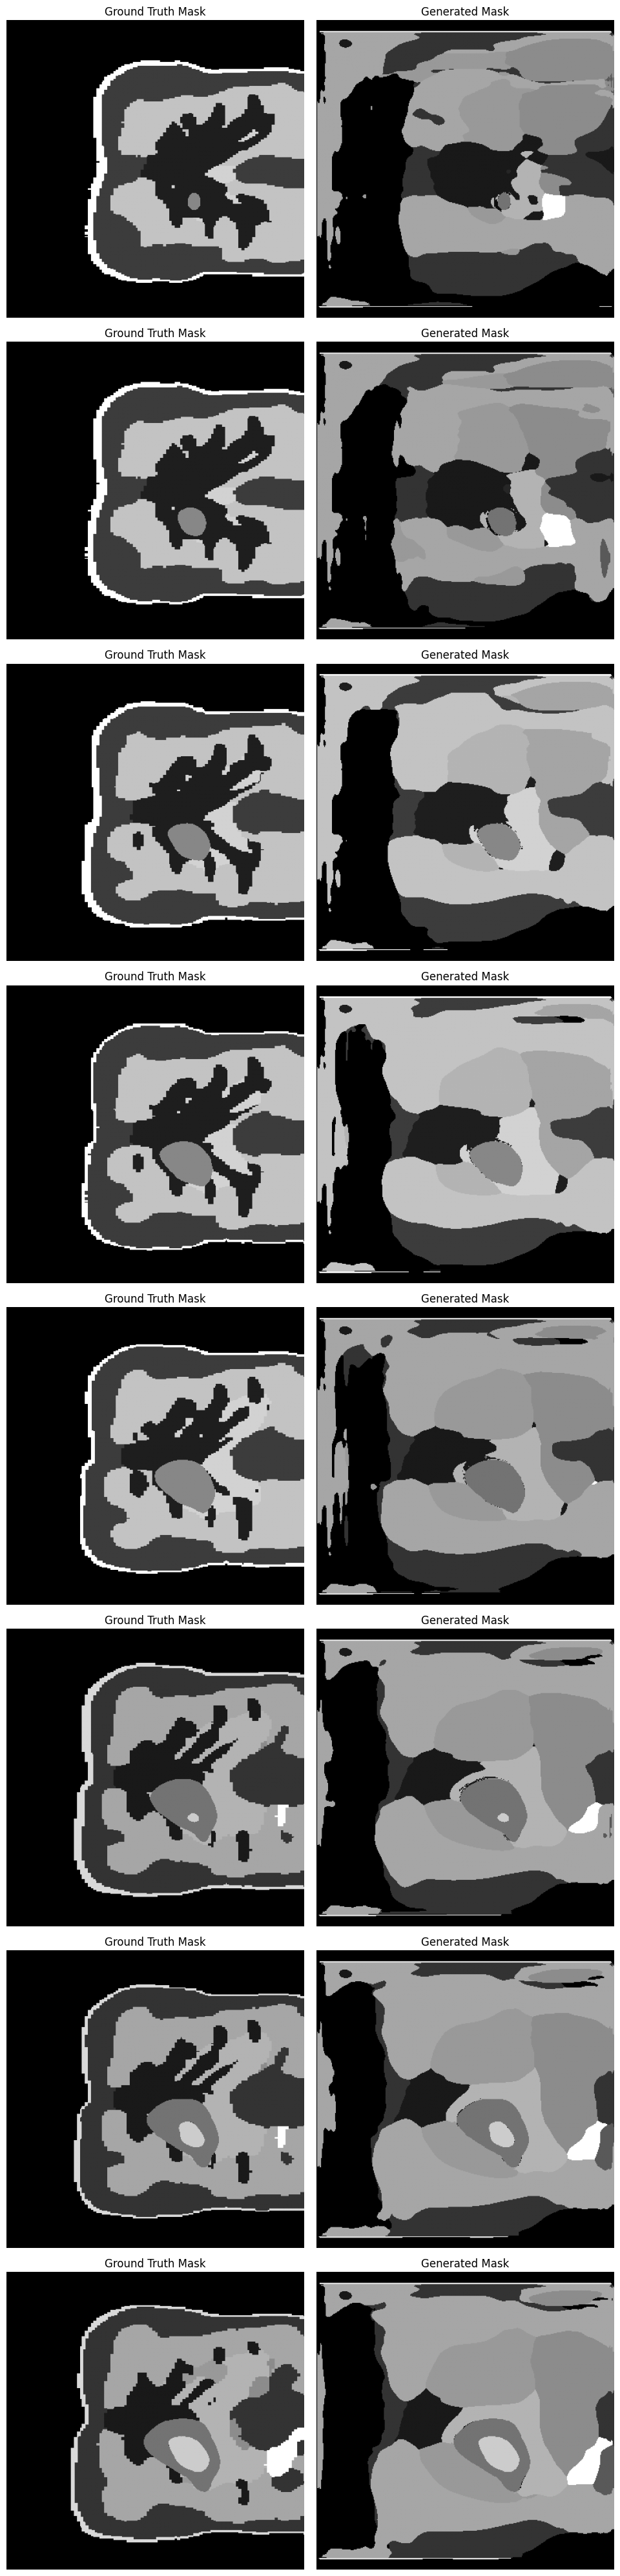

{'num_steps': 15000,
 'n_discr_steps': 1,
 'lambda_ce': 10.0,
 'val_check_interval': 120,
 'batch_size': 8,
 'learning_rate_gen': 0.0001,
 'learning_rate_discr': 1e-05,
 'notes': 'Basic GAN training on DIDC COROV2 data (benchmark), no remapping of labels, no blob size filtering, no thresholding.',
 'patience_es': 15,
 'delta_es': 0.01,
 'dropout_gen': 0.3,
 'num_gpus': 1,
 'validation_fraction': 0.2,
 'target_size': 64,
 'seed': 187,
 'parallel': False,
 'device_ids': None,
 'data_folder': './DIDC_multiclass_coro_v2_prep_old',
 'source_data': 'DIDC_multiclass_coro_v2',
 'rm_black_slices': True,
 'remap_nn': False,
 'threshold_classes': 'None',
 'min_blob_size': 'None',
 'num_input_classes': 4,
 'grouping_rules_used': "{'Background': 'Background', '__unused__': 'Others', 'Other_tissue': 'Others', 'Cartilage_costal': 'Bones_and_cartilage', 'Humerus_left': 'Bones_and_cartilage', 'Scapula_left': 'Bones_and_cartilage', 'Scapula_right': 'Bones_and_cartilage', 'Clavicle_left': 'Bones_and_cart

In [9]:
if os.path.exists(dir_name):
    if os.path.isfile(dir_name + "/config.json") or os.path.isfile(dir_name + "/metrics_history.json"):
        with open(f"{dir_name}/config.json", "r") as f:
            training_config = json.load(f)

        with open(f"{dir_name}/metrics_history.json", "r") as f:
            metrics_history = json.load(f)
    
    if os.path.isfile(dir_name + "/train_val_split.json"):
        with open(f"{dir_name}/train_val_split.json", "r") as f:
            train_val_split = json.load(f)
    
    if os.path.isfile(dir_name + "/grouping_rules_and_labels.json"):
        with open(f"{dir_name}/grouping_rules_and_labels.json", "r") as f:
            grouping_rules_and_labels = json.load(f)
            grouping_rules = grouping_rules_and_labels['grouping_rules']
            new_labels = grouping_rules_and_labels['new_labels']

    if os.path.isfile(DATA_DIR + "/dataset_config.json"):
        with open(f"{DATA_DIR}/dataset_config.json", "r") as f:
            dataset_config = json.load(f)

val_dataset =  FastDatasetDIDC(DATA_DIR, file_list=train_val_split['val_indices'])
dataloader = DataLoader(val_dataset, batch_size=training_config['batch_size'], shuffle=False)
batch = next(iter(dataloader))

n_input_classes = 4
n_output_classes = len(dataset_config['new_labels_used'])
gen = UNetGan(in_ch=n_input_classes, num_classes=n_output_classes, dropout_p=training_config['dropout_gen']).to(device)

# gen = nn.DataParallel(gen)
gen.load_state_dict(torch.load(dir_name+"/best_generator.pth", weights_only=True))
gen.eval()

with torch.no_grad():
    input_label = batch['input_label'].to(device)
    multi_tissue_masks = batch['multiClassMask'].to(device)
    if input_label.dim() > 4:
        input_label = input_label.squeeze(1)
    if multi_tissue_masks.dim() > 3:
        multi_tissue_masks = multi_tissue_masks.squeeze(1)
    output = gen(input_label)

fig, ax = plt.subplots(2, len(metrics_history)//2, figsize=(15, 10))
ax = ax.flatten()
for i, (metric_name, metric_values) in enumerate(metrics_history.items()):
    if metric_name == 'current_step':
        break
    ax[i].plot(metric_values)
    ax[i].set_title(metric_name)
    ax[i].set_ylabel(metric_name)
    ax[i].grid(linestyle='--', alpha=0.5)
plt.tight_layout()

for metric_name, metric_values in metrics_history.items():
    if metric_name == 'current_step':
        continue
    best_value = max(metric_values) if 'loss' not in metric_name else min(metric_values)
    print(f"Best {metric_name}: {best_value:.4f}")

# Plot images
fig, ax = plt.subplots(len(batch['input_label']), 2, figsize=(10, 40))
for i in range(len(batch['input_label'])):
    ax[i, 0].imshow(multi_tissue_masks[i].cpu().numpy(), cmap='gray')
    ax[i, 0].set_title('Ground Truth Mask')
    ax[i, 0].axis('off')

    output_mask = torch.argmax(output[i], dim=0).cpu().numpy()
    ax[i, 1].imshow(output_mask, cmap='gray')
    ax[i, 1].set_title('Generated Mask')
    ax[i, 1].axis('off')

plt.tight_layout()
plt.show()

training_config

## VAE validation

In [ ]:





dir_name = "./experiments/DIDC_VAE/20260225_1651_VAE_KL_train" 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if os.path.exists(dir_name):
    with open(f"{dir_name}/training_config.json", "r") as f:
        training_config = json.load(f)

    with open(f"{dir_name}/metrics_history.json", "r") as f:
        metrics_history = json.load(f)
    
    with open(f"{dir_name}/train_val_split.json", "r") as f:
        train_val_split = json.load(f)


val_dataset = FastDatasetDIDC(training_config['data_path'], file_list=train_val_split['val_indices'])
dataloader = DataLoader(val_dataset, batch_size=min(training_config.get('eval_batch_size', 4), len(val_dataset)), shuffle=True)
batch = next(iter(dataloader))

checkpoint_path = os.path.join(dir_name, "checkpoint_epoch")
model = AutoencoderKL.from_pretrained(checkpoint_path).to(device)
model.eval()

num_classes = training_config['num_input_classes']

with torch.no_grad():
    gt_classes = batch['multiClassMask'].long().to(device)
    if gt_classes.dim() == 4:
        gt_classes = gt_classes.squeeze(1)

    clean_images = F.one_hot(gt_classes, num_classes=num_classes).permute(0, 3, 1, 2).float() 
    clean_images = clean_images * 2.0 - 1.0 

    posterior = model.encode(clean_images).latent_dist
    z = posterior.mode()
    reconstructed_logits = model.decode(z).sample

    output_mask = torch.argmax(reconstructed_logits, dim=1).cpu().numpy()

# Metrics plot
metrics_to_plot = {k: v for k, v in metrics_history.items() if isinstance(v, list)}
n_metrics = len(metrics_to_plot)

fig, ax = plt.subplots(2, (n_metrics + 1) // 2, figsize=(15, 10))
ax = ax.flatten()
for i, (metric_name, metric_values) in enumerate(metrics_to_plot.items()):
    ax[i].plot(metric_values, linewidth=2)
    ax[i].set_title(metric_name.replace('_', ' ').title())
    ax[i].set_ylabel('Value')
    ax[i].set_xlabel('Epochs')
    ax[i].grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("-" * 30)
for metric_name, metric_values in metrics_to_plot.items():
    if len(metric_values) > 0:
        best_value = min(metric_values) if 'loss' in metric_name.lower() else max(metric_values)
        print(f"Best {metric_name}: {best_value:.4f}")
print("-" * 30)

# Visualization
gt_classes_np = gt_classes.cpu().numpy()
batch_size = gt_classes_np.shape[0]

fig, ax = plt.subplots(batch_size, 2, figsize=(10, 5 * batch_size))

if batch_size == 1:
    ax = np.expand_dims(ax, axis=0)

for i in range(batch_size):
    # Plot Ground Truth
    ax[i, 0].imshow(gt_classes_np[i], cmap='gray', vmin=0, vmax=num_classes-1)
    ax[i, 0].set_title(f'Ground Truth Mask {i}')
    ax[i, 0].axis('off')

    # Plot Reconstructed Mask
    ax[i, 1].imshow(output_mask[i], cmap='gray', vmin=0, vmax=num_classes-1)
    ax[i, 1].set_title(f'VAE Reconstructed Mask {i}')
    ax[i, 1].axis('off')

plt.tight_layout()
plt.show()